In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis.out"

data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 640
Dosis mínima: 0.00083703
Dosis máxima: 0.011584
Primeros valores: [0.0060542 0.0056647 0.0060043 0.0034227 0.0036351 0.0038996 0.0033721
 0.0015425 0.0042576 0.0038828]


In [14]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [15]:
file_path = "histograma_dosis.out"
mostrar_encabezados_phits(file_path)
data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

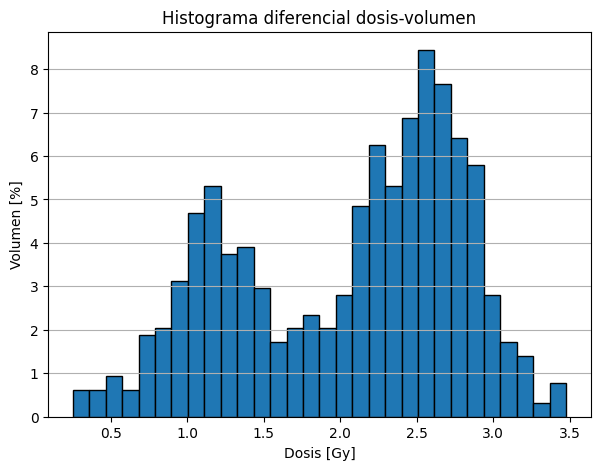

In [16]:
tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [17]:
print(np.std(data_dosis_fisica)/np.mean(data_dosis_fisica))

0.3578169355636157


el primer pico que vemos es debido a que en la mesh estamos agarrando aire, y como en la dosis no hay aire aparece ese pico pronunciado

In [7]:
# volumen total de la mesh: x= 3.2 * y= 2 * z= 0.2
vol_mesh_total = 3.2*2*0.2
print(f"{vol_mesh_total:.2f} cm^3")

1.28 cm^3


In [8]:
vol_pouch = 0.89 # (cm^3)

#entonces

vol_aire = vol_mesh_total - vol_pouch
print(f"Volumen de aire: {vol_aire:.2f} cm^3")

Volumen de aire: 0.39 cm^3


In [9]:
porcentaje_pouch = 100 * vol_pouch / vol_mesh_total
porcentaje_aire = 100 * vol_aire / vol_mesh_total

print(f"Porcentaje de pouch: {porcentaje_pouch:.2f}%")
print(f"Porcentaje de aire: {porcentaje_aire:.2f}%")    

Porcentaje de pouch: 69.53%
Porcentaje de aire: 30.47%


Este histogama nos dice qué porcentaje del volumen recibió una dosis dentro de cada intervalo

Por ejemplo: 

Entre 0.010 y 0.012 Gy/source → 20% del volumen

Entre 0.012 y 0.014 Gy/source → 35% del volumen

Entre 0.014 y 0.016 Gy/source → 25% del volumen

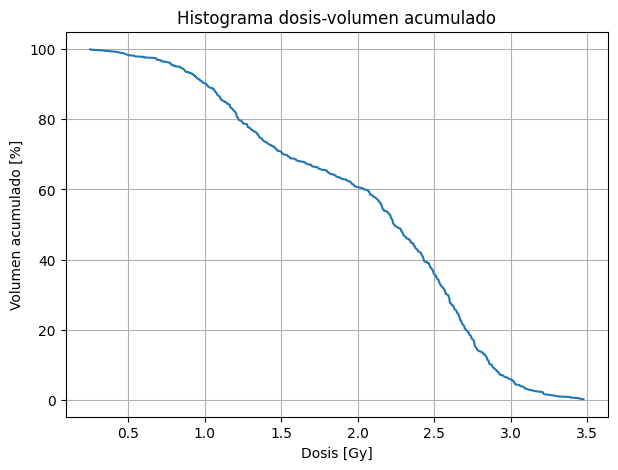

In [18]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

In [11]:
# ─────────────────────────────────────────────
# Índice de homogeneidad: (D2 - D98) / D2
# ─────────────────────────────────────────────

dosis_gy = dosis_ordenada * tiempo_seg  # dosis en Gy (igual que en el plot)

# Invertimos para que np.interp funcione (volumen va de 100 a 0)
vol_inv  = vol_acumulado[::-1]
dosis_inv = dosis_gy[::-1]

D2  = np.interp(2,  vol_inv, dosis_inv)
D98 = np.interp(98, vol_inv, dosis_inv)

HI = (D2 - D98) / D2

print(f"D2  = {D2:.3f} Gy")
print(f"D98 = {D98:.3f} Gy")
print(f"HI  = {HI:.4f}")


D2  = 3.210 Gy
D98 = 0.543 Gy
HI  = 0.8308


In [12]:
np.mean(dosis_ordenada*tiempo_seg)

np.float64(7.137459843749999)

In [13]:
np.std(dosis_ordenada*tiempo_seg)

np.float64(1.4512181697725883)

In [14]:
np.std(dosis_ordenada*tiempo_seg)/np.mean(dosis_ordenada*tiempo_seg)

np.float64(0.20332417996626131)

Este grafico nos dice qué porcentaje del volumen recibió una dosis mayor o igual que cierto valor :

Por ejemplo:

Dosis ≥ 0.010 Gy/source → 100% del volumen

Dosis ≥ 0.012 Gy/source → 80% del volumen

Dosis ≥ 0.014 Gy/source → 45% del volumen

Dosis ≥ 0.016 Gy/source → 20% del volumen

In [11]:
nx = 16
ny = 10
nz = 4

esperados = nx * ny * nz

print("Valores esperados:", esperados)
print("Valores leídos:", len(data_dosis))

if len(data_dosis) != esperados:
    print("Ojo: no se leyó la cantidad esperada de bins.")
else:
    print("Todo ok: se leyeron todos los bins.")

Valores esperados: 640
Valores leídos: 640
Todo ok: se leyeron todos los bins.


## Cálculo del volumen del pouch cortado




El pouch se modeló en PHITS como un elipsoide:

`100 ell 0.0 0.0 61.01  1.6 0.0 0.0  -1.0`

y fue recortado por los planos:

`201 pz 60.58`

`202 pz 60.78`

Interpretamos entonces un elipsoide centrado en:

$$
z_0 = 61.01 \ \mathrm{cm}
$$

con semiejes:

$$
a_x = 1.6 \ \mathrm{cm}
$$

$$
a_y = 1.0 \ \mathrm{cm}
$$

$$
a_z = 1.0 \ \mathrm{cm}
$$

La ecuación del elipsoide es:

$$
\frac{x^2}{a_x^2}
+
\frac{y^2}{a_y^2}
+
\frac{(z-z_0)^2}{a_z^2}
\leq 1
$$

es decir:

$$
\frac{x^2}{1.6^2}
+
\frac{y^2}{1.0^2}
+
\frac{(z-61.01)^2}{1.0^2}
\leq 1
$$

Los planos de corte limitan el volumen entre:

$$
z_1 = 60.58 \ \mathrm{cm}
$$

$$
z_2 = 60.78 \ \mathrm{cm}
$$

Para un valor fijo de $z$, la sección transversal del elipsoide es una elipse. Su área depende de qué tan lejos estemos del centro del elipsoide.

La ecuación del elipsoide se puede escribir como:

$$
\frac{x^2}{a_x^2}
+
\frac{y^2}{a_y^2}
\leq
1-
\frac{(z-z_0)^2}{a_z^2}
$$

Entonces, a cada altura $z$, los semiejes de la sección elíptica quedan reducidos por el factor:

$$
\sqrt{
1-
\frac{(z-z_0)^2}{a_z^2}
}
$$

Por lo tanto, el área de la sección transversal es:

$$
A(z)
=
\pi a_x a_y
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
$$

El volumen del pouch cortado se calcula integrando esa área entre los planos de corte:

$$
V
=
\int_{z_1}^{z_2}
A(z)\,dz
$$

Reemplazando $A(z)$:

$$
V
=
\int_{z_1}^{z_2}
\pi a_x a_y
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
dz
$$

Sacando las constantes fuera de la integral:

$$
V
=
\pi a_x a_y
\int_{z_1}^{z_2}
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
dz
$$

La integral es:

$$
V
=
\pi a_x a_y
\left[
(z-z_0)
-
\frac{(z-z_0)^3}{3a_z^2}
\right]_{z_1}^{z_2}
$$

Reemplazando los valores:

$$
V
=
\pi (1.6)(1.0)
\left[
(z-61.01)
-
\frac{(z-61.01)^3}{3(1.0)^2}
\right]_{60.58}^{60.78}
$$

Definimos:

$$
u = z-z_0
$$

Entonces:

$$
u_1 = z_1-z_0
$$

$$
u_1 = 60.58-61.01
$$

$$
u_1 = -0.43 \ \mathrm{cm}
$$

y:

$$
u_2 = z_2-z_0
$$

$$
u_2 = 60.78-61.01
$$

$$
u_2 = -0.23 \ \mathrm{cm}
$$

Entonces el volumen queda:

$$
V
=
\pi (1.6)(1.0)
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
$$

Evaluamos en el extremo superior:

$$
u_2-\frac{u_2^3}{3}
=
-0.23-\frac{(-0.23)^3}{3}
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.23-\frac{-0.012167}{3}
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.23+0.004056
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.225944
$$

Evaluamos en el extremo inferior:

$$
u_1-\frac{u_1^3}{3}
=
-0.43-\frac{(-0.43)^3}{3}
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.43-\frac{-0.079507}{3}
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.43+0.026502
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.403498
$$

Restamos ambos valores:

$$
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
=
-0.225944 - (-0.403498)
$$

$$
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
=
0.177554
$$

Entonces:

$$
V
=
\pi (1.6)(1.0)(0.177554)
$$

$$
V
=
0.8925 \ \mathrm{cm^3}
$$

Por lo tanto, el volumen aproximado del pouch cortado es:

$$
\boxed{
V_{\mathrm{pouch}} \approx 0.89 \ \mathrm{cm^3}
}
$$

Filas totales leídas : 640
Shape               : (640, 4)

Capa z=1 → z ∈ [98.3800, 98.4300] cm
Vóxeles en la capa : 160
Dosis mín : 7.8276e-01 Gy
Dosis máx : 3.4446e+00 Gy


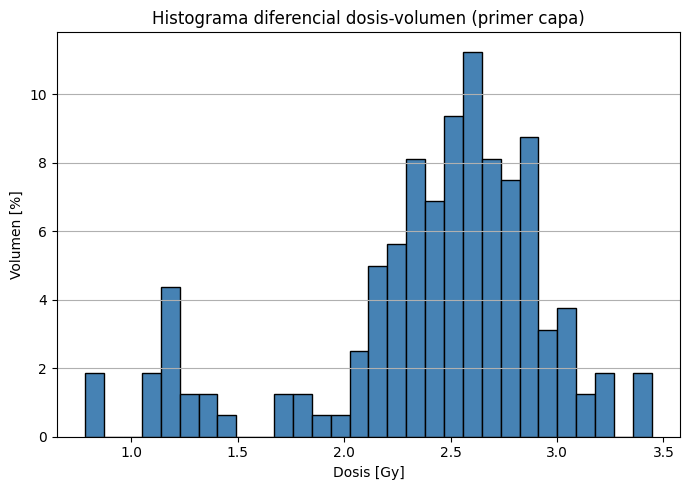

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parámetros del tally ──────────────────────────────────────────
NX, NY, NZ = 16, 10, 4
CAPA_Z = 0          # 0-indexado → 1 = segunda capa

# ── Lector ───────────────────────────────────────────────────────
def leer_dosis_phits_tdeposit(filename):
    filas = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if (linea.startswith("#") or linea.startswith("'") or
                        linea.startswith("ms") or linea.startswith("wt") or
                        linea.startswith("\\") or linea.startswith("e:")):
                    leyendo_tabla = False
                    continue

                partes = linea.split()
                if len(partes) == 4:
                    try:
                        filas.append([float(p) for p in partes])
                    except ValueError:
                        pass

    return np.array(filas)   # shape: (NX*NY*NZ, 4) → columnas: z_low z_up dose rerr


# ── Lectura ───────────────────────────────────────────────────────
file_path = "histograma_dosis.out"
tabla = leer_dosis_phits_tdeposit(file_path)

print(f"Filas totales leídas : {len(tabla)}")
print(f"Shape               : {tabla.shape}")

# ── Extraer SÓLO la segunda capa en Z ────────────────────────────
# PHITS organiza con z como índice más interno (x → y → z)
# → los vóxeles de z=1 están en filas 1, 5, 9, ... (cada NZ filas)
indices_capa2 = np.arange(CAPA_Z, NX * NY * NZ, NZ)
capa2 = tabla[indices_capa2]          # shape (160, 4)

z_low = capa2[0, 0]
z_up  = capa2[0, 1]
print(f"\nCapa z=1 → z ∈ [{z_low:.4f}, {z_up:.4f}] cm")
print(f"Vóxeles en la capa : {len(capa2)}")   # debe dar 160

# ── Dosis física ──────────────────────────────────────────────────
tiempo_seg = 300
dosis_fisica = capa2[:, 2] * tiempo_seg   # columna 2 = dose

print(f"Dosis mín : {dosis_fisica.min():.4e} Gy")
print(f"Dosis máx : {dosis_fisica.max():.4e} Gy")

# ── DVH diferencial ───────────────────────────────────────────────
n_voxeles  = len(dosis_fisica)
vol_voxel  = 100.0 / n_voxeles           # % por vóxel

bins_dosis = 30

vol_por_intervalo, bordes = np.histogram(
    dosis_fisica,
    bins=bins_dosis,
    weights=np.ones(n_voxeles) * vol_voxel
)

centros = 0.5 * (bordes[:-1] + bordes[1:])
anchos  = np.diff(bordes)

plt.figure(figsize=(7, 5))
plt.bar(centros, vol_por_intervalo, width=anchos,
        align="center", edgecolor="black", color="steelblue")

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen (primer capa)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [33]:
print(np.std(dosis_fisica) / np.mean(dosis_fisica))

0.22891764889714947


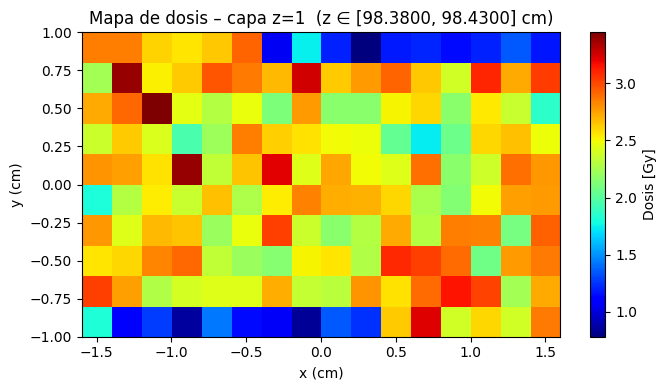

In [36]:
dosis_2d = dosis_fisica.reshape(NY, NX)   # (10, 16)

plt.figure(figsize=(7, 4))
plt.imshow(dosis_2d, origin="lower", aspect="auto",
           extent=[-1.6, 1.6, -1.0, 1.0], cmap="jet")
plt.colorbar(label="Dosis [Gy]")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.title(f"Mapa de dosis – capa z=1  (z ∈ [{z_low:.4f}, {z_up:.4f}] cm)")
plt.tight_layout()
plt.show()

Valores leídos: 4000  (esperado: 4000 = 50×80)
Perfil en x = 0.0800 cm  (bin 25)


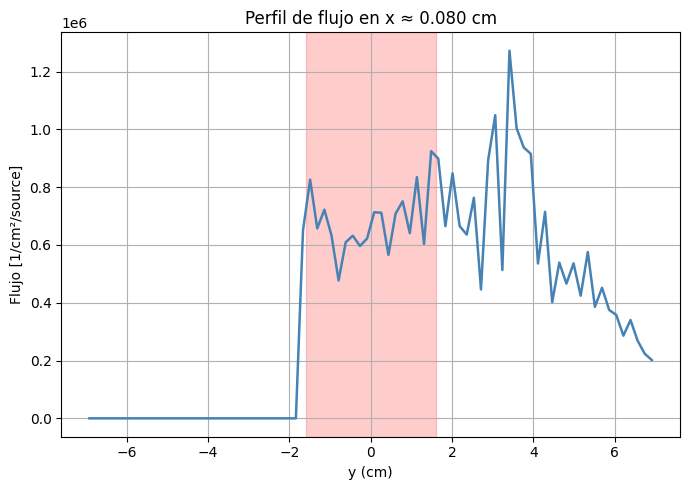

In [49]:
import numpy as np
import matplotlib.pyplot as plt

NX, NY = 50, 80
XMIN, XMAX = -4., 4.
YMIN, YMAX = -7., 7.

x_centers = np.linspace(XMIN, XMAX, NX, endpoint=False) + (XMAX - XMIN) / (2 * NX)
y_centers = np.linspace(YMIN, YMAX, NY, endpoint=False) + (YMAX - YMIN) / (2 * NY)

def leer_ttrack_xy(filename, nx, ny):
    valores = []
    leyendo = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            # Los datos empiezan después de la línea "hc:"
            if linea.startswith("hc:"):
                leyendo = True
                continue

            if leyendo:
                # Cualquier línea que no sea número puro detiene la lectura
                try:
                    for val in linea.split():
                        valores.append(float(val))
                except ValueError:
                    break

    arr = np.array(valores)
    print(f"Valores leídos: {len(arr)}  (esperado: {nx*ny} = {nx}×{ny})")

    # Shape: (NY, NX), pero y viene de mayor a menor → flip
    flux_2d = arr.reshape(NY, NX)
    flux_2d = np.flipud(flux_2d)   # ahora y va de -7 a +7
    return flux_2d

# ── Lectura ───────────────────────────────────────────────────────
flux_2d = leer_ttrack_xy("track_xy.out", NX, NY)   # shape (80, 50)

# ── Perfil en x=0 ─────────────────────────────────────────────────
ix_centro = np.argmin(np.abs(x_centers))
print(f"Perfil en x = {x_centers[ix_centro]:.4f} cm  (bin {ix_centro})")

perfil_y = flux_2d[:, ix_centro]   # todos los y, x fijo en 0

plt.figure(figsize=(7, 5))
plt.plot(y_centers, perfil_y, color="steelblue", linewidth=1.8)
plt.axvspan(-1.6, 1.6, alpha=0.2, color="red", label="pouch")
plt.xlabel("y (cm)")
plt.ylabel("Flujo [1/cm²/source]")
plt.title(f"Perfil de flujo en x ≈ {x_centers[ix_centro]:.3f} cm")
plt.grid(True)
plt.tight_layout()
plt.show()